Running 5 trials to average results...


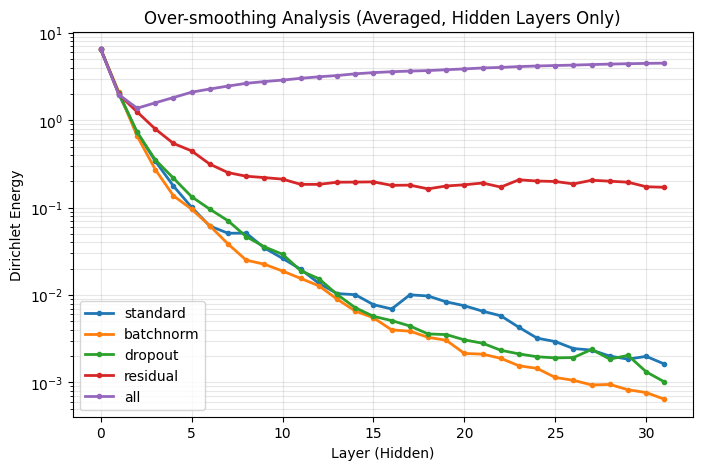

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, BatchNorm, LayerNorm
from torch_geometric.datasets import Planetoid
import matplotlib.pyplot as plt
import numpy as np        

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_dirichlet_energy(x, edge_index):
    x_norm = F.normalize(x, p=2, dim=-1) 
    
    row, col = edge_index
    # E(X) = ||x_i - x_j||^2
    diff = x_norm[row] - x_norm[col]
    energy = (diff.norm(dim=1, p=2) ** 2).sum()
    return (energy / x.size(0)).item()

class DeepGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers, 
                 mode='standard'):
        super().__init__()
        self.layers = torch.nn.ModuleList()
        self.norms = torch.nn.ModuleList() 
        self.num_layers = num_layers
        self.mode = mode
        if num_layers < 2:
            self.layers.append(GCNConv(in_channels, out_channels))
            return

        # Input
        self.layers.append(GCNConv(in_channels, hidden_channels))
        if mode == 'batchnorm':
            self.norms.append(BatchNorm(hidden_channels))
        else:
            self.norms.append(LayerNorm(hidden_channels))

        # Hidden
        for _ in range(num_layers - 2):
            self.layers.append(GCNConv(hidden_channels, hidden_channels))
            if mode == 'batchnorm':
                self.norms.append(BatchNorm(hidden_channels))
            else:
                self.norms.append(LayerNorm(hidden_channels))

        # Output
        self.layers.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x, edge_index, return_energies=False):
        energies = []
        if return_energies:
            energies.append(get_dirichlet_energy(x, edge_index))

        for i, conv in enumerate(self.layers[:-1]):
            x_in = x
            x = conv(x, edge_index)
            
            if self.mode == 'batchnorm':
                x = self.norms[i](x)
            
            x = F.relu(x)
            
            if self.mode == 'dropout':
                x = F.dropout(x, p=0.6, training=self.training)
            
            if self.mode == 'residual' and x.shape == x_in.shape:
                x = x + x_in 
                x = F.normalize(x, p=2, dim=1) 

            if self.mode == 'all' and x.shape == x_in.shape:
                x = self.norms[i](x) 
                x = F.dropout(x, p=0.6, training=self.training)
                x = x + x_in
            # -------------------
            
            if return_energies:
                energies.append(get_dirichlet_energy(x, edge_index))

        # Final layer
        x = self.layers[-1](x, edge_index)
        
        if return_energies:
            energies.append(get_dirichlet_energy(x, edge_index))
            return energies
        else:
            return F.log_softmax(x, dim=1)


def run_experiment_refined():
    dataset = Planetoid(root='/tmp/Cora', name='Cora')
    data = dataset[0].to(device)
    num_layers = 32
    hidden_dim = 64
    
    modes = ['standard', 'batchnorm', 'dropout', 'residual', 'all']
    results = {m: [] for m in modes}
    
    # 跑 5 次取平均，消除抖动
    print("Running 5 trials to average results...")
    for _ in range(5):
        for mode in modes:
            model = DeepGCN(dataset.num_features, hidden_dim, dataset.num_classes, num_layers, mode=mode).to(device)
            model.eval()
            with torch.no_grad():
                energies = model(data.x, data.edge_index, return_energies=True)
                results[mode].append(energies[:-1]) 

    # 绘图
    plt.figure(figsize=(8, 5))
    for name, runs in results.items():
        # 计算平均值
        avg_energies = np.mean(np.array(runs), axis=0)
        plt.plot(range(len(avg_energies)), avg_energies, label=name, linewidth=2, marker='o', markersize=3)

    plt.yscale('log')
    plt.xlabel('Layer (Hidden)')
    plt.ylabel('Dirichlet Energy')
    plt.title('Over-smoothing Analysis (Averaged, Hidden Layers Only)')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.show()

run_experiment_refined()


# 训练与准确率

Start Training Experiment on cuda...

Evaluating Mode: standard
  Depth 1: Best Test Acc = 0.7520
  Depth 2: Best Test Acc = 0.8130
  Depth 3: Best Test Acc = 0.8030
  Depth 4: Best Test Acc = 0.7960
  Depth 8: Best Test Acc = 0.7520
  Depth 16: Best Test Acc = 0.2740
  Depth 32: Best Test Acc = 0.2620

Evaluating Mode: residual
  Depth 1: Best Test Acc = 0.7460
  Depth 2: Best Test Acc = 0.8140
  Depth 3: Best Test Acc = 0.7880
  Depth 4: Best Test Acc = 0.7820
  Depth 8: Best Test Acc = 0.7770
  Depth 16: Best Test Acc = 0.7380
  Depth 32: Best Test Acc = 0.7550

Evaluating Mode: batchnorm
  Depth 1: Best Test Acc = 0.7490
  Depth 2: Best Test Acc = 0.7810
  Depth 3: Best Test Acc = 0.7660
  Depth 4: Best Test Acc = 0.7780
  Depth 8: Best Test Acc = 0.6900
  Depth 16: Best Test Acc = 0.6750
  Depth 32: Best Test Acc = 0.5110

Evaluating Mode: all
  Depth 1: Best Test Acc = 0.7450
  Depth 2: Best Test Acc = 0.8120
  Depth 3: Best Test Acc = 0.7820
  Depth 4: Best Test Acc = 0.7900
  D

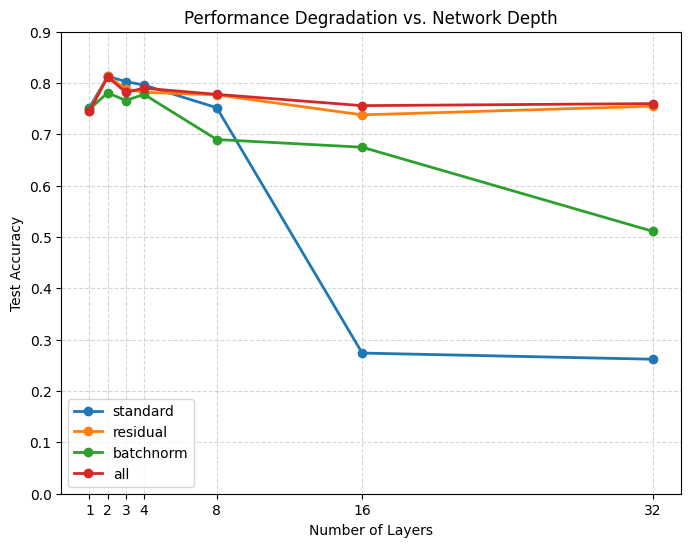

In [ ]:
def train_model(model, data, epochs=200, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    best_acc = 0.0
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        # 注意：这里调用时不传 return_energies，默认返回 logits
        out = model(data.x, data.edge_index)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
        # 简单的验证逻辑
        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                pred = model(data.x, data.edge_index).argmax(dim=1)
                acc = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()
                if acc > best_acc:
                    best_acc = acc
    return best_acc

def run_training_experiment():
    dataset = Planetoid(root='/tmp/Cora', name='Cora')
    data = dataset[0].to(device)
    
    depths = [1, 2, 3, 4, 8, 16, 32]
    modes = ['standard', 'residual', 'batchnorm', 'all']
    
    final_results = {mode: [] for mode in modes}
    
    print(f"Start Training Experiment on {device}...")
    
    for mode in modes:
        print(f"\nEvaluating Mode: {mode}")
        for depth in depths:
            model = DeepGCN(
                in_channels=dataset.num_features,
                hidden_channels=64,
                out_channels=dataset.num_classes,
                num_layers=depth,
                mode=mode
            ).to(device)
            
            acc = train_model(model, data)
            final_results[mode].append(acc)
            print(f"  Depth {depth}: Best Test Acc = {acc:.4f}")

    plt.figure(figsize=(8, 6))
    for mode, accs in final_results.items():
        plt.plot(depths, accs, label=mode, marker='o', linewidth=2)
    
    plt.title('Performance Degradation vs. Network Depth')
    plt.xlabel('Number of Layers')
    plt.ylabel('Test Accuracy')
    plt.xticks(depths)
    plt.ylim(0, 0.9)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    run_training_experiment()

Running Bonus Experiment (Aggressive DropEdge)...


/tmp/ipykernel_53168/125079700.py:40: UserWarning: 'dropout_adj' is deprecated, use 'dropout_edge' instead
  current_edge_index, _ = dropout_adj(edge_index, p=0.8, force_undirected=True)


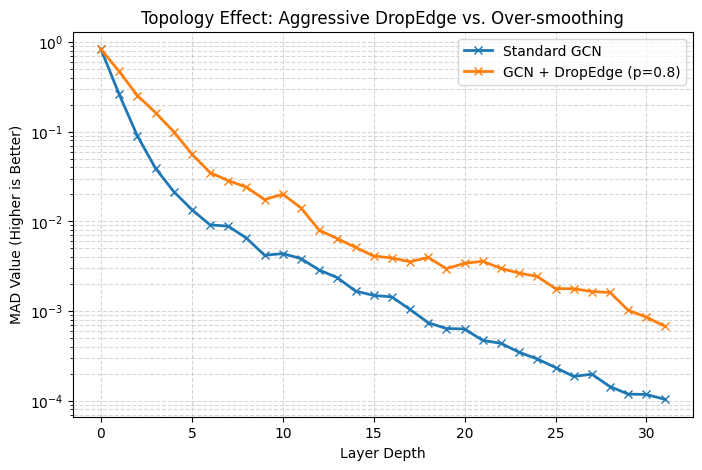

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import dropout_adj
from torch_geometric.datasets import Planetoid
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_mad(x, edge_index):
    # MAD Metric: 越高越好
    x_norm = F.normalize(x, p=2, dim=-1)
    row, col = edge_index
    cosine = (x_norm[row] * x_norm[col]).sum(dim=1).clamp(-1, 1)
    return (1 - cosine).mean().item()

class BonusGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers, use_dropedge=False):
        super().__init__()
        self.layers = torch.nn.ModuleList()
        self.num_layers = num_layers
        self.use_dropedge = use_dropedge

        self.layers.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.layers.append(GCNConv(hidden_channels, hidden_channels))
        self.layers.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x, edge_index, return_metric=False):
        mad_values = []
        if return_metric: mad_values.append(get_mad(x, edge_index))

        for i, conv in enumerate(self.layers[:-1]):
            current_edge_index = edge_index
            if self.use_dropedge:
                current_edge_index, _ = dropout_adj(edge_index, p=0.8, force_undirected=True)
            
            x = conv(x, current_edge_index)
            x = F.relu(x)
            
            if return_metric: mad_values.append(get_mad(x, edge_index))

        # Final layer
        x = self.layers[-1](x, edge_index)
        if return_metric: 
            mad_values.append(get_mad(x, edge_index))
            return mad_values
        return F.log_softmax(x, dim=1)

def run_bonus_final():
    print("Running Bonus Experiment (Aggressive DropEdge)...")
    dataset = Planetoid(root='/tmp/Cora', name='Cora')
    data = dataset[0].to(device)
    num_layers = 32
    
    configs = {
        'Standard GCN': False,
        'GCN + DropEdge (p=0.8)': True 
    }
    
    results = {name: [] for name in configs}

    for _ in range(5):
        for name, use_dropedge in configs.items():
            model = BonusGCN(dataset.num_features, 64, dataset.num_classes, num_layers, use_dropedge).to(device)
            model.eval() 
            with torch.no_grad():
                mads = model(data.x, data.edge_index, return_metric=True)
                results[name].append(mads[:-1])

    plt.figure(figsize=(8, 5))
    for name, runs in results.items():
        avg_mads = np.mean(np.array(runs), axis=0)
        plt.plot(avg_mads, label=name, marker='x', linewidth=2)
    
    plt.yscale('log')
    plt.xlabel('Layer Depth')
    plt.ylabel('MAD Value (Higher is Better)')
    plt.title('Topology Effect: Aggressive DropEdge vs. Over-smoothing')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

if __name__ == "__main__":
    run_bonus_final()

结论：dropEdge只有在很高的rate时才有效。需要更好的方法才能缓解这个问题。